## **도구(툴) 활용**

**LLM에 도구(툴)가 필요한 이유**는 4가지로 정리됩니다.

1. 모르는 것 — 지식의 시간적 한계
학습 시점 이후의 정보(오늘 날씨, 최신 뉴스, 우리 회사 내부 문서)는 알 수 없습니다. → 검색, RAG로 보완

2. 못하는 것 — 정확한 계산/결정적 로직
LLM은 다음 토큰을 확률적으로 예측하는 방식이라, 정밀한 수치 계산이나 복잡한 로직은 틀리기 쉽습니다. → 계산기, 코드 실행에 위임

3. 할 수 없는 것 — 실제 행동
텍스트를 생성할 뿐, 이메일을 보내거나 DB에 쓰거나 캘린더에 등록하는 건 LLM 혼자서는 불가능합니다. → API 호출로 실행을 대신

4. 믿을 수 없는 것 — 환각(hallucination)
모르는 걸 그럴듯하게 지어낼 수 있습니다. → 외부 도구로 근거를 확인하고 답변에 반영

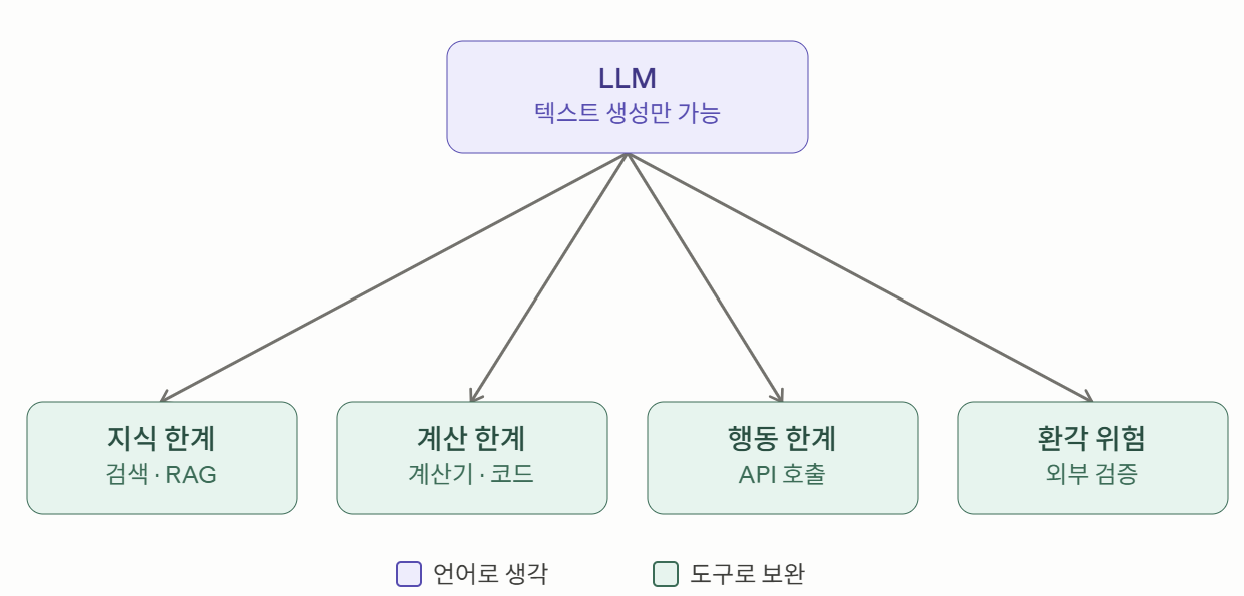

**LLM은 "언어로 생각하는 두뇌"고 도구는 "세상과 연결되는 손과 눈"**

둘이 합쳐져야 ReAct 같은 에이전트가 실제로 쓸모 있어집니다.

In [ ]:
from dotenv import load_dotenv

load_dotenv()

In [ ]:
from openai import OpenAI

client = OpenAI()
# 최신 Responses API 호출 방식
response = client.responses.create(
    model="gpt-4o-mini",    
    input="지금 몇 시야? 그리고 오늘 날짜도 알려줘.",
    max_output_tokens=500,
    temperature=0.7
)
print(response.output_text)

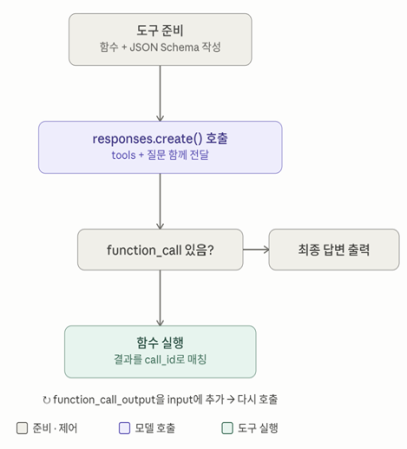

1. Python 함수를 작성하는데 반환값은 JSON으로 직렬화 가능한 dict 형태여야 함
2. 함수를 모델이 "보고 판단"할 수 있도록 JSON Schema로 노출
3. client.responses.create(model=..., instructions=..., input=질문, tools=툴 정보 리스트) 호출

In [ ]:
import datetime
import json
from openai import OpenAI

# 1. 실제 실행될 파이썬 함수(Tool) 정의
def get_current_time() -> str:
    """현재 시스템 시간을 구하는 함수"""
    now = datetime.datetime.now()
    return json.dumps({"current_time": now.strftime("%Y-%m-%d %H:%M:%S")})

# 툴을 쉽게 매핑하기 위한 딕셔너리
available_tools = {
    "get_current_time": get_current_time
}

# 2. OpenAI 모델에게 전달할 Tool의 명세(Schema) 정의
tools_specification = [
    {
        "type": "function",
        "name": "get_current_time",
        "description": "사용자가 현재 시간, 오늘 날짜, 지금 시각 등을 물어볼 때 실시간 시스템 정보를 가져옵니다.",
        "parameters": {
            "type": "object",
            "properties": {} # 전달할 인자(Argument)가 없으므로 비워둡니다.
        }
    }
]

In [ ]:
from dotenv import load_dotenv

load_dotenv()

def main():
    # SDK가 환경 변수(OPENAI_API_KEY)를 자동으로 인식합니다.
    client = OpenAI()

    # 입력 데이터를 축적할 리스트 생성 (Responses API의 대화 상태 저장 방식)
    input_history = [
        {"role": "user", "content": "지금 몇 시야? 그리고 오늘 날짜도 알려줘."}
    ]

    print(f"사용자 질문: {input_history[0]['content']}\n")
    print("--- AI Agent Loop 시작 ---")

    # 3. 툴 실행 루프 (모델이 더 이상 툴을 호출하지 않고 최종 답변을 낼 때까지 반복)
    while True:
        response = client.responses.create(
            model="gpt-4o-mini",
            instructions="당신은 친절한 어시스턴트입니다. 정보를 답변할 때 필요하다면 제공된 도구를 적극적으로 사용하세요.",
            input=input_history,
            tools=tools_specification
        )

        # 모델이 생성한 출력 목록을 다음 루프의 컨텍스트에 누적 (.output에는 text나 function_call 등이 담김)
        input_history += response.output

        # 이번 턴에 모델이 툴 호출(function_call)을 요청했는지 확인
        has_tool_call = False

        print(response.output)
        
        for item in response.output:
            if item.type == "function_call":
                has_tool_call = True
                tool_name = item.name
                tool_call_id = item.call_id
                
                print(f"[AI 요청]: 툴 '{tool_name}' 실행이 필요합니다. (Call ID: {tool_call_id})")

                # 실제 파이썬 함수 매칭 및 실행
                if tool_name in available_tools:
                    tool_function = available_tools[tool_name]
                    tool_result = tool_function()
                    print(f"[툴 실행 결과]: {tool_result}")

                    #Responses API 형식에 맞춰 실행 결과를 input_history에 추가
                    input_history.append({
                        "type": "function_call_output",
                        "call_id": tool_call_id,
                        "output": tool_result
                    })
                else:
                    print(f"에러: {tool_name} 이라는 도구를 찾을 수 없습니다.")

        # 모델이 더 이상 툴을 호출하지 않았다면, 최종 자연어 답변이 완성된 것이므로 루프 종료
        if not has_tool_call:
            print("\n--- AI Agent Loop 종료 ---")
            # Responses API 전용 편리한 텍스트 추출 속성 사용
            print(f"\n최종 AI 답변:\n{response.output_text}")
            break

if __name__ == "__main__":
    main()

In [ ]:
from openai import OpenAI

client = OpenAI()
# 최신 Responses API 호출 방식
response = client.responses.create(
    model="gpt-4o-mini",    
    input="지금 서울 날씨 어때?",
    max_output_tokens=500,
    temperature=0.7
)
print(response.output_text)

In [ ]:
from openai import OpenAI

# 1. 실제 날씨 정보를 API로 읽어오는 파이썬 함수
def get_current_weather(location: str) -> str:
    """
    지정된 도시(location)의 실시간 날씨 정보를 오픈 API에서 가져옵니다.
    """
    try:
        # wttr.in은 전 세계 도시명을 기반으로 날씨 데이터를 JSON으로 리턴하는 무료 오픈 서비스입니다.
        # ?format=j1 옵션을 주면 상세한 실시간 날씨 JSON 데이터를 얻을 수 있습니다.
        url = f"https://wttr.in/{location}?format=j1"
        response = requests.get(url, timeout=5)
        
        if response.status_code == 200:
            data = response.json()
            # 가장 최신 실시간 날씨 데이터 가공
            current_condition = data['current_condition'][0]
            temp_c = current_condition['temp_C']         # 현재 기온 (섭씨)
            weather_desc = current_condition['lang_ko'][0]['value'] if 'lang_ko' in current_condition else current_condition['weatherDesc'][0]['value'] # 날씨 상태 설명
            humidity = current_condition['humidity']       # 습도
            
            return json.dumps({
                "location": location,
                "temperature_celsius": f"{temp_c}°C",
                "condition": weather_desc,
                "humidity": f"{humidity}%"
            }, ensure_ascii=False)
        else:
            return json.dumps({"error": f"도시 '{location}'의 날씨 정보를 찾을 수 없습니다."})
            
    except Exception as e:
        return json.dumps({"error": f"날씨 정보를 가져오는 중 오류 발생: {str(e)}"})

# 함수 매핑 딕셔너리
AVAILABLE_TOOLS = {
    "get_current_weather": get_current_weather
}


# 2. OpenAI 규격에 맞춘 날씨 툴 명세 (인자값 구조 정의)
TOOLS_SPECIFICATION = [
    {
        "type": "function",
        "name": "get_current_weather",
        "description": "특정 도시나 국가명을 입력받아 실시간 날씨, 기온, 습도 정보를 조회합니다.",
        "parameters": {
            "type": "object",
            "properties": {
                # 💡 모델이 추출해야 할 변수(location)의 스펙을 정의합니다.
                "location": {
                    "type": "string",
                    "description": "날씨를 조회할 영문 도시명 (예: 'Seoul', 'Tokyo', 'London', 'New York')"
                }
            },
            "required": ["location"] # 이 인자값은 필수임을 명시
        }
    }
]

In [ ]:
# 3. 메인 에이전트 실행 루프
def main():
    client = OpenAI() # 환경변수 OPENAI_API_KEY 자동 연동

    # 질문 예시 (한국어로 질문해도 모델이 인자값은 영어 도시명으로 알아서 변환해 줍니다)
    input_history = [
        {"role": "user", "content": "지금 서울 날씨 어때? 그리고 런던 날씨도 같이 확인해줘."}
    ]

    print(f"💬 사용자 질문: {input_history[0]['content']}\n")
    print("🤖 Agent Loop 가동 시작...")

    while True:
        response = client.responses.create(
            model="gpt-4o-mini",
            instructions="당신은 기상 캐스터 어시스턴트입니다. 제공된 도구를 사용해 실시간 정보를 얻어 사용자에게 친절하게 안내하세요.",
            input=input_history,
            tools=TOOLS_SPECIFICATION
        )

        # 모델 응답 결과 누적
        input_history += response.output
        has_tool_call = False

        for item in response.output:
            if item.type == "function_call":
                has_tool_call = True
                tool_name = item.name
                tool_call_id = item.call_id
                
                # 💡 핵심: 모델이 사용자 문장에서 지능적으로 발라낸 arguments(인자값)를 파싱합니다.
                # 예: {"location": "Seoul"}
                tool_args = json.loads(item.arguments) if hasattr(item, 'arguments') and item.arguments else {}
                
                print(f"👉 [AI 요청]: 툴 '{tool_name}' 실행 필요 (매개변수: {tool_args})")

                if tool_name in AVAILABLE_TOOLS:
                    tool_func = AVAILABLE_TOOLS[tool_name]
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         
                    # 💡 딕셔너리 언패킹(**tool_args)을 통해 location='Seoul' 형태로 함수에 인자를 주입합니다.
                    tool_result = tool_func(**tool_args)
                    print(f"   [실행 완료]: 실시간 데이터 가져옴 -> {tool_result}")

                    # 결과값을 에이전트 대화 기록에 백업
                    input_history.append({
                        "type": "function_call_output",
                        "call_id": tool_call_id,
                        "output": tool_result
                    })

        # 더 이상 호출할 도구가 없다면 자연어 답변을 완성하고 루프 탈출
        if not has_tool_call:
            print("\n🤖 Agent Loop 종료.")
            print(f"\n✨ 최종 AI 답변:\n{response.output_text}")
            break

if __name__ == "__main__":
    main()

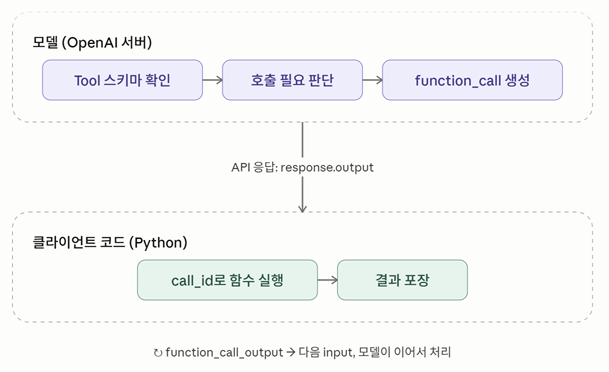

**1단계: 개발자 ➡ LLM (질문과 메뉴판 전달)**
- 하는 일: "서울 날씨 어때?"라는 질문과 함께, 사용할 수 있는 툴 목록(JSON Schema)을 LLM에 보냅니다.

**2단계: LLM ➡ 애플리케이션 (판단 및 호출 요청)**
- 하는 일: LLM은 정보를 분석한 뒤, 본인이 직접 날씨를 확인하는 게 아니라 "내가 판단해보니 get_current_weather 함수를 location='서울'로 실행해야겠어. 나한테 그 결과값 좀 가져다줄래?" 하고 호출 문서(Tool Calls JSON)를 생성하여 응답합니다.

**3단계: 애플리케이션 (실제 함수 호출 주체 🌟)**
- 하는 일: 파이썬 코드가 LLM의 응답을 받아 tool_calls가 포함되어 있는지 확인합니다. 포함되어 있다면, 개발자가 작성한 실제 파이썬 함수를 호출(get_current_weather('서울'))하여 결과 데이터(JSON)를 얻어냅니다.

**4단계: 애플리케이션 ➡ LLM (결과 전달 및 최종 답변)**
- 하는 일: 애플리케이션이 함수 실행 결과(예: {"temp": 22})를 다시 LLM에게 전송합니다. LLM은 이 데이터를 바탕으로 사람이 읽을 수 있는 최종 답변("현재 서울의 날씨는 22도입니다.")을 만들어 사용자에게 전달합니다.

**LLM의 역할: "이 함수를 이런 값으로 실행해라" 하고 결정(Decision)하는 역할.**

**애플리케이션(코드)의 역할: LLM의 결정을 보고 파이썬 함수를 실제 실행(Execution)하는 역할.**

**Schema 작성 원칙**

- 좋은 Tool Schema는 “모델이 추측하지 않아도 되게” 만드는 게 핵심입니다.

```
{
    "type": "function",
    "name": "verb_noun",
    "description": (
        "One-sentence purpose. "
        "Use this when ... "
        "Do not use this when ..."
    ),
    "strict": True,
    "parameters": {
        "type": "object",
        "properties": {
            "arg1": {
                "type": "string",
                "description": "Exact meaning, expected format, and example."
            },
            "arg2": {
                "type": ["string", "null"],
                "description": "Optional value. Use null if not specified."
            }
        },
        "required": ["arg1", "arg2"],
        "additionalProperties": False
    }
}
```

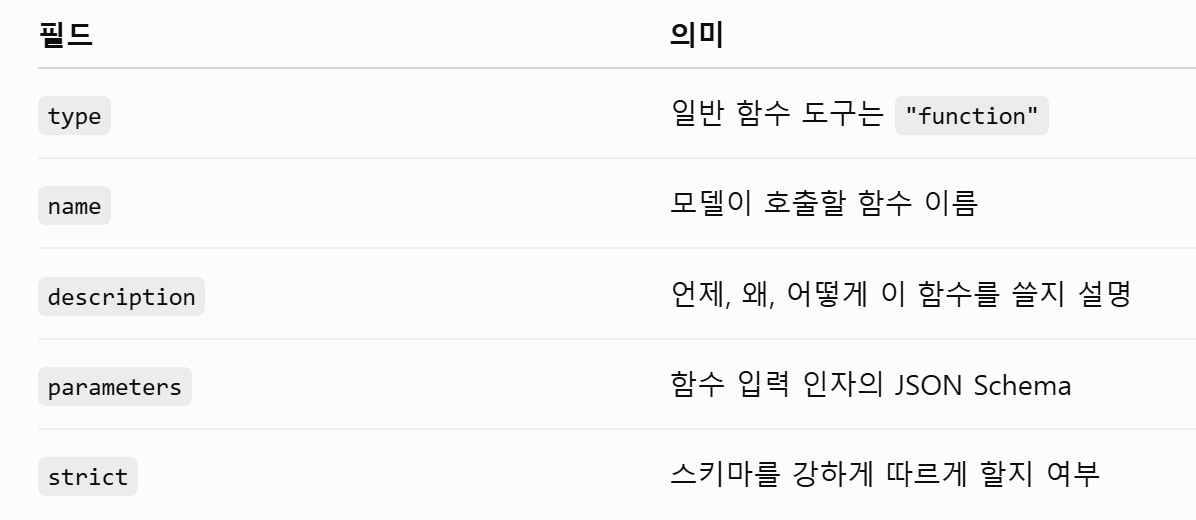

**Open AI의 도구 종류**

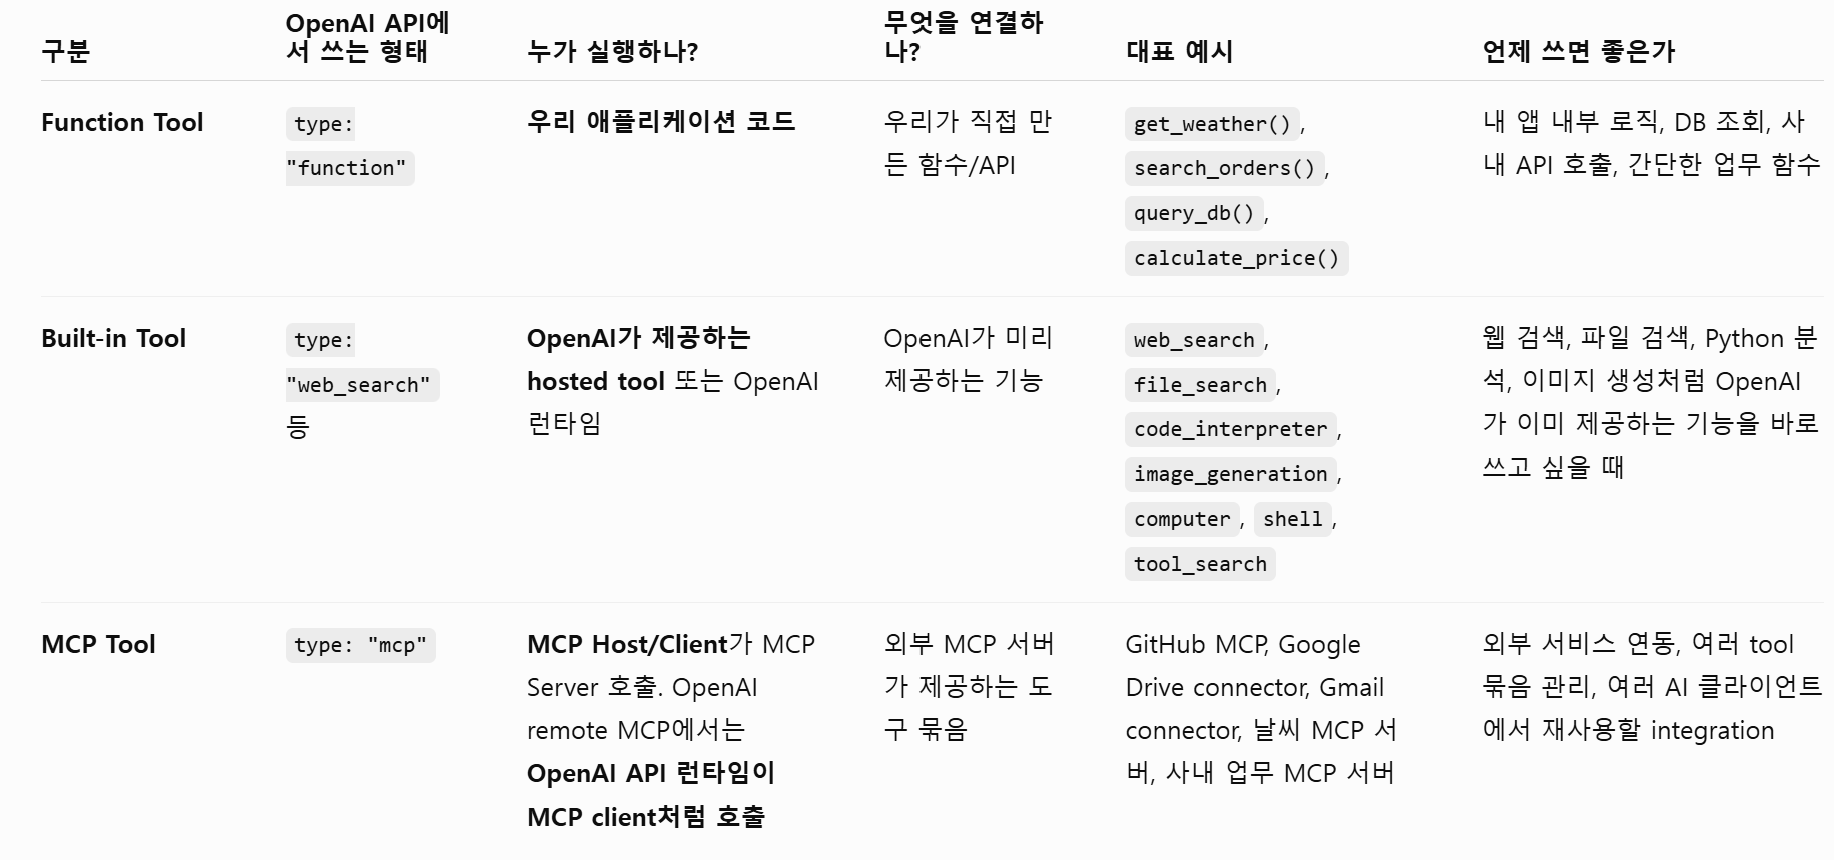

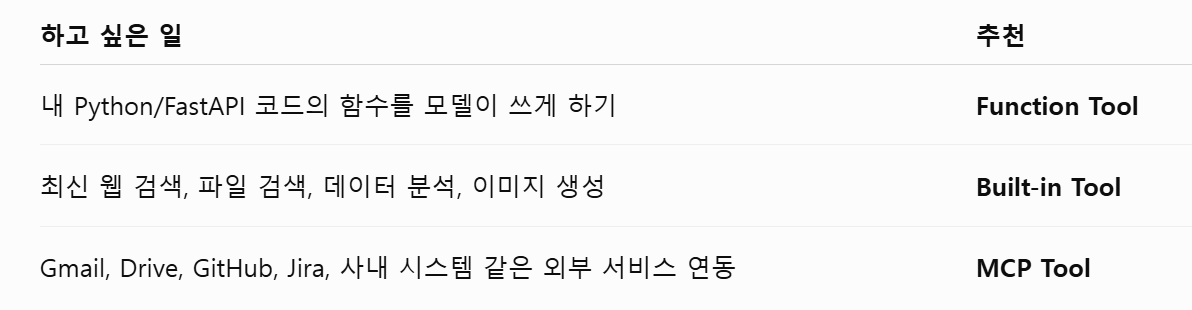

- 빌트인 툴 종류
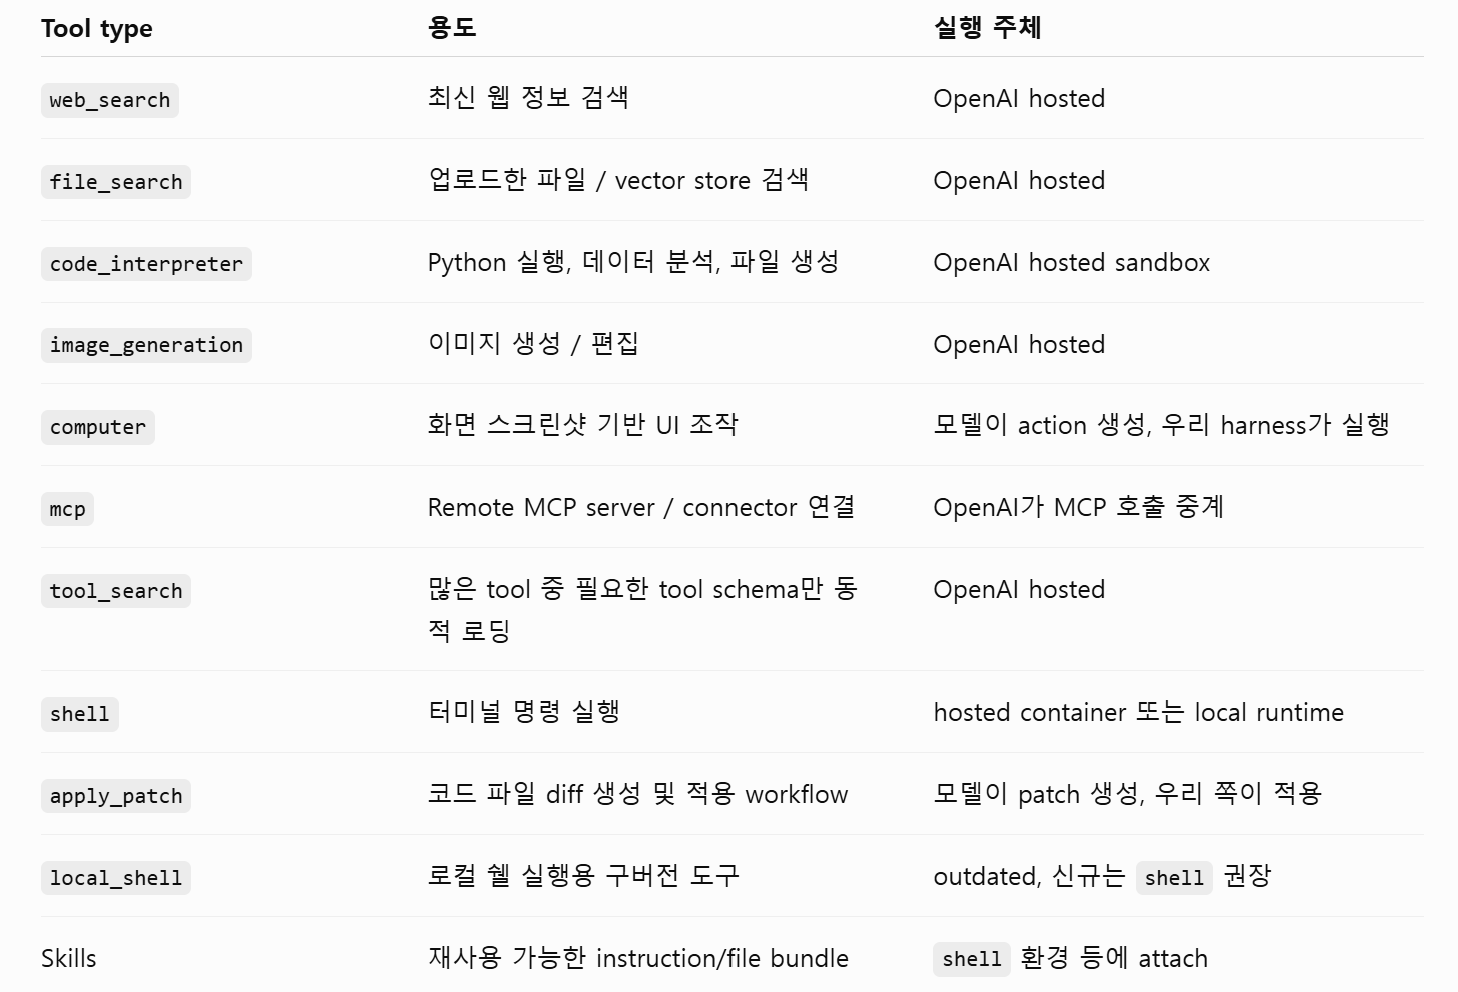

In [ ]:
from openai import OpenAI

client = OpenAI()

response = client.responses.create(
    model="gpt-4o-mini",
    input="오늘 중요한 AI 뉴스 알려줘",
    tools=[
        {"type": "web_search"}
    ]
)

print(response.output_text)

**MCP Tool**

- Function tool은 “내 앱 코드 안에 직접 등록한 함수”이고, MCP tool은 “외부 MCP 서버가 제공하는 도구들을 표준 프로토콜로 연결한 것”입니다.

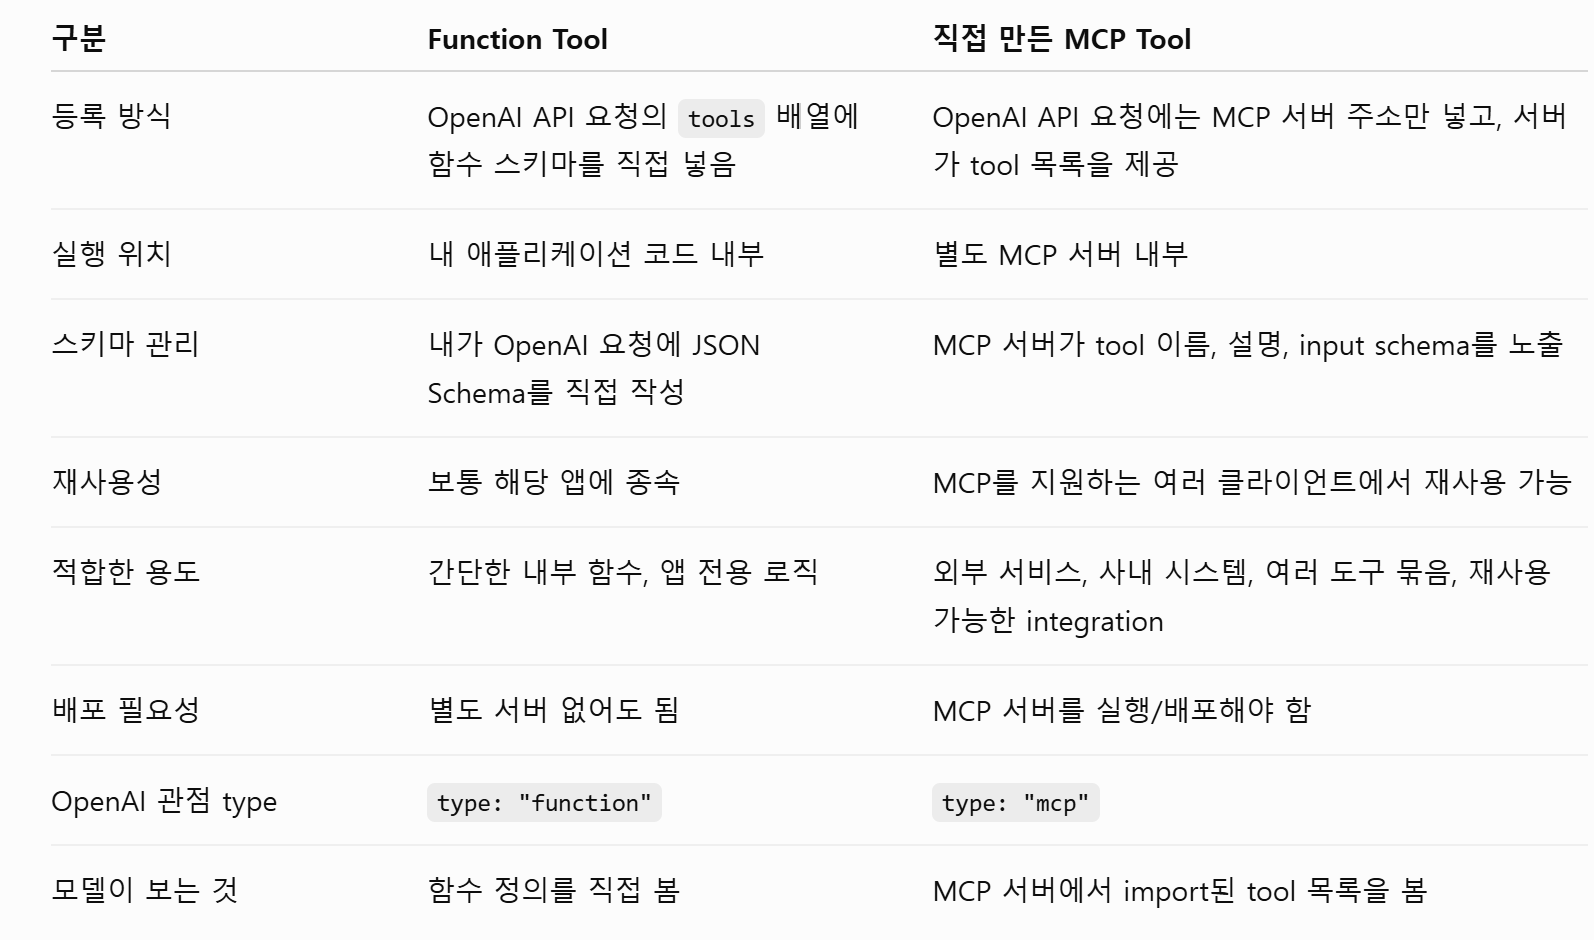

In [ ]:
from openai import OpenAI

client = OpenAI()

response = client.responses.create(
    model="gpt-4o-mini",
    input="서울의 현재 날씨와 대기질을 간단히 알려줘.",
    tools=[
        {
            "type": "mcp",
            "server_label": "korea_weather",
            "server_url": "https://mcp.open-mcp.org/api/server/korea-weather@latest/mcp",
            "require_approval": "never",
            "allowed_tools": [
                "tool_get_current_weather_post",
                "tool_get_air_quality_post",
            ],
        }
    ],
)

print(response.output_text)

---

## **다중  LLM 활용**
-  순차 Multi-LLM + GPT 종합 구조

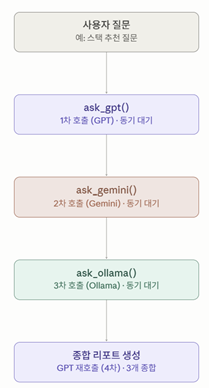

In [ ]:
import os
from openai import OpenAI
from google import genai

# 각 LLM의 클라이언트 초기화 (환경 변수 기반)
# 1. OpenAI (gpt-4o-mini)
openai_client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))

# 2. Google (gemini-2.5-flash) - 최신 공식 google-genai SDK 규격
google_client = genai.Client(api_key=os.environ.get("GEMINI_API_KEY"))

# 3. 로컬 오픈소스 모델 (Ollama - EXAONE 3.5 또는 Llama 3.1)
# Ollama는 OpenAI의 API 규격과 100% 호환되므로 OpenAI 클라이언트를 재활용하면 가장 심플합니다.
ollama_client = OpenAI(
    base_url="http://localhost:11434/v1",
    api_key="ollama" # 로컬이므로 아무 문자열이나 넣어도 됩니다.
)

def ask_gpt(prompt: str) -> str:
    """OpenAI gpt-4o-mini 호출 (최신 Responses API 구조)"""
    try:
        response = openai_client.responses.create(
            model="gpt-4o-mini",
            instructions="당신은 분석적이고 객관적인 IT 전문가입니다.",
            input=prompt
        )
        return response.output_text
    except Exception as e:
        return f"OpenAI 에러: {e}"

def ask_gemini(prompt: str) -> str:
    """Google gemini-2.5-flash 호출 (최신 2.0 SDK 구조)"""
    try:
        response = google_client.models.generate_content(
            model='gemini-2.5-flash',
            contents=prompt,
        )
        return response.text
    except Exception as e:
        return f"Gemini 에러: {e}"

def ask_ollama(prompt: str) -> str:
    """로컬 Ollama 호출 (Llama3.1 또는 EXAONE-3.5 선택)"""
    try:
        # 사용 중인 로컬 모델명으로 변경하세요 (예: 'exaone3.5:7b' 또는 'llama3.1')
        model_name = "exaone3.5" 
        
        response = ollama_client.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": prompt}]
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"Ollama 에러 (모델 확인 필요): {e}"

# --- 메인 실행 흐름 ---
def main():
    # 공통 유저 질문
    user_question = "초보 개발자의 첫 웹 백엔드 스택으로 Python FastAPI와 Java Spring Boot 중 무엇을 더 추천하나요?"
    
    print(f"❓ 공동 질문: '{user_question}'\n")
    print("==============================================")
    print("🔄 1단계: 3개의 다중 LLM에게 동시에 의견 묻는 중...")
    print("==============================================\n")
    
    # 1. 개별 LLM 답변 수집
    gpt_answer = ask_gpt(user_question)
    print(f"🤖 [OpenAI gpt-4o-mini 답변 완료]\n")
    
    gemini_answer = ask_gemini(user_question)
    print(f"♊ [Google gemini-2.5-flash 답변 완료]\n")
    
    ollama_answer = ask_ollama(user_question)
    print(f"🦙 [Ollama 로컬 모델 답변 완료]\n")
    
    # 2. 3개의 답변을 합쳐서 2단계 취합 프롬프트 생성
    synthesis_prompt = f"""
    당신은 수석 아키텍처이자 마스터 멘토입니다. 
    아래는 동일한 질문에 대해 3개의 서로 다른 AI 모델(GPT, Gemini, 오픈소스 모델)이 내놓은 답변입니다.
    
    [질문]
    {user_question}
    
    ---
    [AI 1: GPT의 의견]
    {gpt_answer}
    
    ---
    [AI 2: Gemini의 의견]
    {gemini_answer}
    
    ---
    [AI 3: 오픈소스 모델의 의견]
    {ollama_answer}
    ---
    
    위 3가지 시각을 종합 분석하여, 공통적인 핵심 권장 사항을 추려내고, 
    각 AI의 답변 스타일 차이점을 가볍게 평가하는 '최종 종합 가이드 리포트'를 깔끔한 마크다운 양식으로 작성해 주세요.
    """
    
    print("==============================================")
    print("🔄 2단계: 수집된 의견들을 종합 요약하는 중 (by gpt-4o-mini)...")
    print("==============================================\n")
    
    # 가장 판단력이 안정적인 gpt-4o-mini에게 종합 정리 요청
    final_report = ask_gpt(synthesis_prompt)
    
    # 3. 최종 결과 출력
    print("✨ [최종 다중 LLM 취합 리포트] ✨\n")
    print(final_report)

if __name__ == "__main__":
    main()

In [ ]:
from concurrent.futures import ThreadPoolExecutor

def main():
    user_question = "초보 개발자의 첫 웹 백엔드 스택으로 Python FastAPI와 Java Spring Boot 중 무엇을 더 추천하나요?"

    print(f"❓ 공동 질문: '{user_question}'\n")
    print("==============================================")
    print("🔄 1단계: 3개의 다중 LLM에게 동시에 의견 묻는 중...")
    print("==============================================\n")

    with ThreadPoolExecutor(max_workers=3) as executor:
        futures = {
            "GPT": executor.submit(ask_gpt, user_question),
            "Gemini": executor.submit(ask_gemini, user_question),
            "Ollama": executor.submit(ask_ollama, user_question),
        }

        gpt_answer = futures["GPT"].result()
        print("🤖 [OpenAI gpt-4o-mini 답변 완료]\n")

        gemini_answer = futures["Gemini"].result()
        print("♊ [Google gemini-2.5-flash 답변 완료]\n")

        ollama_answer = futures["Ollama"].result()
        print("🦙 [Ollama 로컬 모델 답변 완료]\n")

    synthesis_prompt = f"""
    당신은 수석 아키텍처이자 마스터 멘토입니다. 
    아래는 동일한 질문에 대해 3개의 서로 다른 AI 모델(GPT, Gemini, 오픈소스 모델)이 내놓은 답변입니다.

    [질문]
    {user_question}

    ---
    [AI 1: GPT의 의견]
    {gpt_answer}

    ---
    [AI 2: Gemini의 의견]
    {gemini_answer}

    ---
    [AI 3: 오픈소스 모델의 의견]
    {ollama_answer}
    ---

    위 3가지 시각을 종합 분석하여, 공통적인 핵심 권장 사항을 추려내고, 
    각 AI의 답변 스타일 차이점을 가볍게 평가하는 '최종 종합 가이드 리포트'를 깔끔한 마크다운 양식으로 작성해 주세요.
    """

    print("==============================================")
    print("🔄 2단계: 수집된 의견들을 종합 요약하는 중 (by gpt-4o-mini)...")
    print("==============================================\n")

    final_report = ask_gpt(synthesis_prompt)

    print("✨ [최종 다중 LLM 취합 리포트] ✨\n")
    print(final_report)

In [ ]:
main()

**다중 LLM - 순차 파이프라인 패턴**

- Gemini 2.5 Flash → **시스템 아키텍트** (고수준 설계/명세 작성에 강점)
- Ollama/EXAONE 3.5 (로컬) → **풀스택 개발자** (실제 코드 생성)
- gpt-4o-mini → ***시니어 QA 리뷰어** (엄격한 검증/판정)

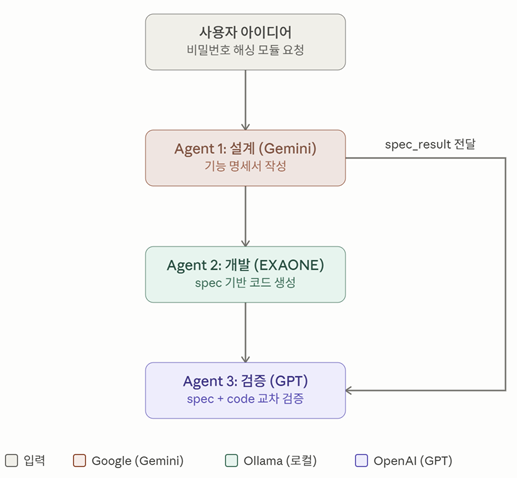

In [ ]:
import inspect
from openai import OpenAI
from google import genai

# 1. 2026년 기준 가장 최신 규격의 클라이언트 선언
# OpenAI Responses API용 클라이언트
openai_client = OpenAI() 

# Google 최신 공식 google-genai SDK용 클라이언트 (환경변수 GEMINI_API_KEY 자동 매핑)
google_client = genai.Client()

# 로컬 오픈소스용 클라이언트 (OpenAI SDK로 Ollama 최신 v1 표준 엔드포인트 연동)
ollama_client = OpenAI(
    base_url="http://localhost:11434/v1",
    api_key="ollama"
)

# -------------------------------------------------------------
# Agent 1: Google Gemini 2.5 Flash (역할: 시스템 아키텍트)
# -------------------------------------------------------------
def run_planner_agent(user_idea: str) -> str:
    print("▶️ [Agent 1] Gemini 아키텍트가 설계 명세서를 작성 중입니다...")
    
    prompt = inspect.cleandoc(f"""
        당신은 전설적인 시스템 아키텍트입니다. 
        사용자의 아이디어를 바탕으로, 개발자가 즉시 코딩에 착수할 수 있도록 구체적인 '기능 명세서'를 작성하세요.
        반드시 포함할 내용: 필요한 함수 목록, 입력/출력 데이터 타입, 예외 처리 기준.
        
        [사용자 아이디어]: {user_idea}
    """)
    
    # google-genai 최신 표준 메서드 호출
    response = google_client.models.generate_content(
        model='gemini-2.5-flash',
        contents=prompt,
    )
    return response.text

# -------------------------------------------------------------
# Agent 2: Ollama / EXAONE 3.5 (역할: 풀스택 개발자)
# -------------------------------------------------------------
def run_developer_agent(spec_document: str) -> str:
    print("▶️ [Agent 2] 로컬 오픈소스 개발자가 코드를 구현 중입니다...")
    
    prompt = inspect.cleandoc(f"""
        당신은 천재 파이썬 개발자입니다. 
        전달받은 [기능 명세서]를 100% 반영하여 구동 가능한 깔끔한 파이썬 소스 코드를 작성하세요.
        설명은 생략하고 마크다운 코드 블록(```python ... ```) 안에 코드만 완벽하게 작성하세요.
        
        [기능 명세서]:
        {spec_document}
    """)
    
    # Ollama Chat Completion 표준 API 호출
    response = ollama_client.chat.completions.create(
        model="exaone3.5", 
        messages=[{"role": "user", "content": prompt}]
    )
    return response.choices[0].message.content

# -------------------------------------------------------------
# Agent 3: OpenAI gpt-4o-mini (역할: 시니어 QA 리뷰어)
# -------------------------------------------------------------
def run_reviewer_agent(original_spec: str, generated_code: str) -> str:
    print("▶️ [Agent 3] GPT 시니어 리뷰어가 완성된 코드를 최종 검증 중입니다...")
    
    user_prompt = inspect.cleandoc(f"""
        당신은 엄격한 시니어 개발자이자 QA 엔지니어입니다.
        [개발자가 작성한 코드]가 원래의 [기능 명세서] 규칙을 모두 준수했는지 교차 검증하세요.
        버그 가능성이나 개선 방향을 짚어주고, 최종 승인 여부(Pass/Fail)를 판정하세요.
        
        [원래 기능 명세서]:
        {original_spec}
        
        [개발자가 작성한 코드]:
        {generated_code}
    """)
    
    # 순수 OpenAI 최신 표준 Responses API 활용
    response = openai_client.responses.create(
        model="gpt-4o-mini",
        instructions="당신은 엄격하고 논리적인 코드 검증 및 품질 리뷰 어시스턴트입니다.",
        input=user_prompt
    )
    return response.output_text


# -------------------------------------------------------------
# 🚀 메인 오케스트레이션 파이프라인
# -------------------------------------------------------------
def main():
    user_idea = "사용자가 회원가입할 때 비밀번호를 입력받아 안전하게 해싱(SHA-256)하고, 솔트(Salt)를 추가하여 검증까지 해주는 간단한 보안 모듈을 만들어줘."
    
    print(f"💡 [User Request]: {user_idea}\n")
    print("==================================================================")
    print("🤖 최신 API 기반 멀티 에이전트 파이프라인 가동")
    print("==================================================================\n")
    
    # 1단계: 설계 (Gemini)
    spec_result = run_planner_agent(user_idea)
    print("✅ [Gemini] 설계 명세서 작성 완료.\n")
    
    # 2단계: 개발 (Ollama - EXAONE 3.5)
    code_result = run_developer_agent(spec_result)
    print("✅ [Ollama] 소스 코드 빌드 완료.\n")
    print("--- [생성된 소스 코드] ---")
    print(code_result)
    print("\n")
    
    # 3단계: 검증 (OpenAI)
    final_review = run_reviewer_agent(spec_result, code_result)
    print("✅ [OpenAI] 최종 QA 및 코드 리뷰 완료.\n")
    
    print("==================================================================")
    print("✨ [최종 파이프라인 합작 결과 리포트]")
    print("==================================================================\n")
    print(final_review)

if __name__ == "__main__":
    main()